### Demography terms with which I am not familiar.

* **Vital rates** - how fast vital statistics (eg birth or death rate) change in a population 
* **Stable stage distribution** - the distribution/proportion of the population at different developmental stages when said population has reached a constant/stable state
* **Reproductive value** - (from RA Fisher, 1930) the number of female children that will be born to a female of a specific age (ie how much she will contribute to the future population)
* **Survival probability** - the likelihood that an individual in a stage will survive (live long enough) and progress onto the next stage


## Overview

We wish to build a basic "toy" model of the South African population, using 5-year age bucketed population data, live birth rates and mortality rates. For this we use a matrix population modelling method, as described in Sensitivity Analysis: Matrix Methods in Demography and Ecology, Hal Caswell (2019). 

Historical methods of demographic analysis (eg Hamilton, 1966) are limited by the implicit assumption that vital rates (how fast vital statistics change in a population) are directly associated with age. This is not the case, especially in humans, where factors such as education level, marriage and spatial location contribute important information towards modelling vital rates. With this in mind, stage-classified demographic models were developed, classifying individuals by their life stage, rather than chronilogical age. For this basic "toy" model of the South African population, we use a special case of stage-classification: an age-classified model (?). 

Stage-classified demography can be analysed using matrix methods (Leslie, 1945; Caswell 2001). We require:
* a population vector $\mathbf{n}(t)$, where each element is the number of individuals in each age class at time $t$ (we use 5 year age buckets; 0-4, 5-9 etc) and
* a population projection matrix $\mathbf{A}$ such that the dominant eigenvalue of the matrix, $\lambda$ describes the discrete-time population growth rate.

Then, the model uses $\mathbf{A}$ to calculate the population at the next time step $\mathbf{n}(t+1)$ using the equation:
  $$\mathbf{n}(t+1) = \mathbf{A}\mathbf{n}(t)$$

It follows that the stable stage distribution is given by the right eigenvector $\mathbf{w}$ corresponding to $\lambda$ and the the reproductive value function byt the left eigenvector $\mathbf{v}$. These satisfy
$$\mathbf{Aw}=\lambda\mathbf{w}$$
$$\mathbf{v^T A}=\lambda\mathbf{v^T}$$

The effects of peturbations on population growth (eg, a baby boom amongst certain age groups) can be estimated through sensitivity analysis of the eigenvector $\lambda$ to changes in an entry $a_{\textit{i, j}}$ of a matrix (Caswell, 1978):

$$\frac{\partial\lambda}{\partial a_\textit{i,j}}=\frac{v_i w_j}{\mathbf{v^T w}} \tag{1}$$

Then by equation $\tag{1}$, we can find the sensitivity of population growth rate $\lambda$ to fertility and survival rate:
$$\frac{\partial\lambda}{\partial \mathbf{P}_i}=\frac{v_{i+1} w_i}{\mathbf{v^T w}}\tag{2}$$
$$\frac{\partial\lambda}{\partial \mathbf{F}_i}=\frac{v_{1} w_i}{\mathbf{v^T w}}\tag{3}$$

Equation $\tag{1}$ peturbs only a single entry of $\mathbf{A}$. We use matrix calculus to generalise this method by considering $\lambda$ as a scalar function of $\mathbf{A}$ and $\mathbf{A}$ as a matrix-valued function of parameter vector $\mathbf{\theta}$. Thus:

$$\begin{align}
\frac{d\lambda}{d \mathbf{\theta^T}} 
&= \frac{d\lambda}{d\text{vec}^T\mathbf{A}} \frac{d\text{vec}\mathbf{A}}{d\mathbf{\theta^T}} \\
&= \frac{\mathbf{w^T}\otimes\mathbf{v^T}}{\mathbf{v^T w}}\frac{d\text{vec}\mathbf{A}}{d\mathbf{\theta^T}}
\end{align}$$

## South African population modelling: a (static) age-classified model

Consider an age-classified model for the South African population:   
$$\mathbf{n}(t+1) = \mathbf{A}\mathbf{n}(t)$$

We need the initial population vector $\mathbf{n}_0$. We also need to construct $\mathbf{A}$, an age-classified matrix (or Leslie matrix) with fertilities $F_i$ in the first row, survival probabilities $P_i$ on the subdiagonal, and zeros everywhere else (Leslie, 1945; Keyfitz 1968). 

$$
\mathbf{A} = \begin{pmatrix}
F_1 & F_2 & F_3 & \dots & F_{i-1} & F_i \\
P_1 & 0   & 0   & \dots & 0       & 0   \\
0   & P_2 & 0   & \dots & 0       & 0   \\
0   & 0   & P_3 & \dots & 0       & 0   \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
0   & 0   & 0   & \dots & P_{i-1} & 0
\end{pmatrix}
$$

Here, $F_i$ refers to the number of children born to a mother in age group $i$ and survival probabilities refers to the likelihood of an individual surviving from age group $i$ to the next age group $i+1$. We calculate each as follows:
$$F_i = \frac{\text{number of births}}{\text{total population}}=\frac{f_i}{n_i}$$

$$P_i = \frac{\text{total population}-\text{deaths}}{\text{total population}} = \frac{n_i - m_i}{n_i}$$




For this model, we use the available Statistics South Africa data with 5-year age buckets ($x=5$) from 0-4 to 80+, thus $i=\{1,2,...,17\}$. Now, $\Delta x = \Delta t$, so since our age intervals are 5 years wide, the time step of the model ($t \to t+1$) is also 5 years **(i think?)**. 

**NB**

This model assumes:
* stationary assumption, where we assume the age-specific fertility and mortality rates are constant over an extended period
* zero net migration
  


### Data:

* We use the 2022 Census data for the initial population vector $\mathbf{n}_0$,
* the Recorded Live Births (2022) report from Stats SA and (link is down 18/05 https://www.statssa.gov.za/publications/P0305/P03052022.pdf)
* the Mortality and causes of death in South Africa: Findings from death notification (2022) report from Stats SA (https://www.statssa.gov.za/publications/P03093/P030932022.pdf). 


#### Setup and importing data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import fractional_matrix_power

In [2]:
# import files, 
# clean: remove 'Total' ROWS, ensure all values are numeric and do not contain ","

file_path = 'Data/BirthDeathPop_2022.xlsx'

births_df = pd.read_excel(file_path, sheet_name=0)   
deaths_df  = pd.read_excel(file_path, sheet_name=1)  
pop_df = pd.read_excel(file_path, sheet_name=2)

def clean_sheet_by_index(df):
    # Filter out total rows 
    df = df[~df.iloc[:, 0].astype(str).str.contains('Total|total', na=False)].copy()

    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.strip(), errors='coerce')
    return df.reset_index(drop=True)

births_df = clean_sheet_by_index(births_df)
deaths_df = clean_sheet_by_index(deaths_df)
pop_df = clean_sheet_by_index(pop_df)

In [3]:
births_df.head()

,Mother's Age,Number of Live Births,Percentage (%)
0,00–04,0,0.0
1,05–09,0,0.0
2,10–14,3598,0.4
3,15–19,101569,11.1
4,20–24,203766,22.3


In [4]:
deaths_df.head()

,Age Group,Number of Deaths,Percentage (%)
0,00–04,44785,8.1
1,05–09,4286,0.8
2,10–14,4524,0.8
3,15–19,10723,1.9
4,20–24,18349,3.3


In [5]:
pop_df.head()

,Sex,Male,Female,Total
0,00–04,2918292,2915222,5833515
1,05–09,2561963,2547141,5109104
2,10–14,2713448,2690676,5404124
3,15–19,2504677,2470633,4975309
4,20–24,2670986,2638753,5309738


In [6]:
# pull relevant values into birth, death and population vectors

# births - need to pad the upper ages with 0s
# we ignore the 242 births where the mother's age is unspecified or outside of 10-55 range

birth_counts = births_df.iloc[:,1].values
num_valid_groups = min(len(birth_counts), 11) 
births = np.zeros(17)
births[:num_valid_groups] = birth_counts[:num_valid_groups]

# deaths
deaths = deaths_df.iloc[:, 1].values

# population count
pop_male = pop_df.iloc[:, 1].values
pop_female = pop_df.iloc[:, 2].values
n_t = pop_df.iloc[:, 3].values

print(f"Births vector shape: {births.shape}")
print(f"Deaths vector shape: {deaths.shape}")
print(f"Population vector (Total) shape: {n_t.shape}")

Births vector shape: (17,)
Deaths vector shape: (17,)
Population vector (Total) shape: (17,)


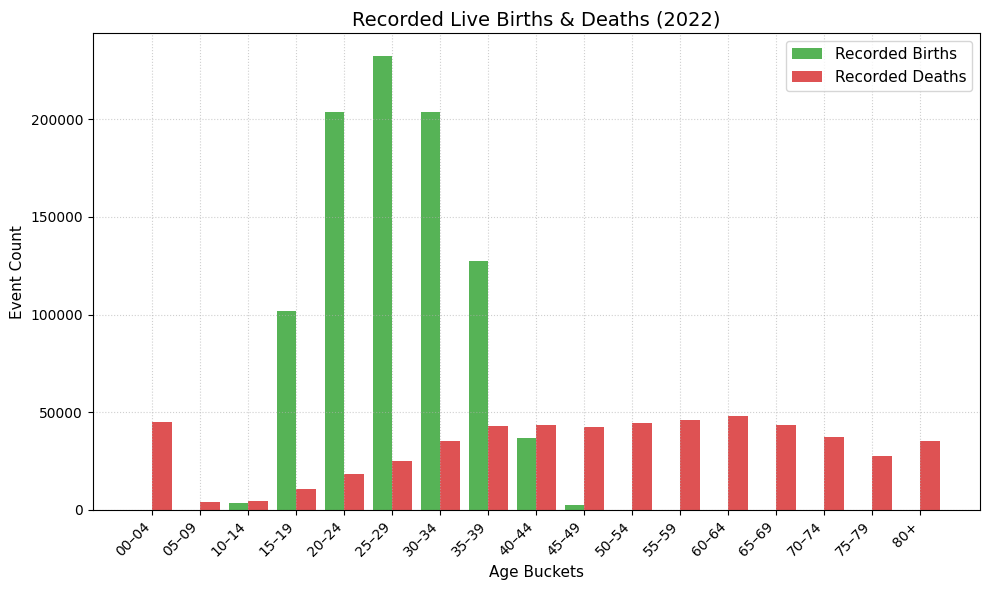

In [7]:
age_groups = [
    "00–04", "05–09", "10–14", "15–19", "20–24", "25–29", "30–34", "35–39",
    "40–44", "45–49", "50–54", "55–59", "60–64", "65–69", "70–74", "75–79", "80+"]

plt.figure(figsize=(10, 6))

x_indexes = np.arange(len(age_groups))
bar_width = 0.4

plt.bar(x_indexes - bar_width/2, births, width=bar_width, color='#2ca02c', alpha=0.8, label='Recorded Births')
plt.bar(x_indexes + bar_width/2, deaths, width=bar_width, color='#d62728', alpha=0.8, label='Recorded Deaths')

plt.title('Recorded Live Births & Deaths (2022)', fontsize=14)
plt.xlabel('Age Buckets', fontsize=11)
plt.ylabel('Event Count', fontsize=11)
plt.xticks(x_indexes, age_groups, rotation=45, ha='right')
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig("Graphs/births_and_deaths_2022.pdf", dpi=300)
plt.show()

### Age-classified matrix method for population projection


In [8]:
# Find F and P
# n_t is total population vector from 2022 Census
# we adjust F and P since these are figures for 1 year, and we need for 5 years
# this assumes constant birth/death rates over the 5 years

# Calculate fertility rates F_i
F = (births / n_t) * 5 

# Caluclate survival probabilities P_i
# we need i-1 elements as P_i goes along thw subdiagonal
P_annual = ((n_t - deaths) / n_t)
P_adjusted = (P_annual ** 5)
P = P_adjusted[:-1]

for i in range(17):
    f_val = F[i]
    p_val = P[i] if i < 16 else 0.0
    print(f"Age Group {i+1}: F = {f_val:.4f}, P = {p_val:.4f}")

Age Group 1: F = 0.0000, P = 0.9622
Age Group 2: F = 0.0000, P = 0.9958
Age Group 3: F = 0.0033, P = 0.9958
Age Group 4: F = 0.1021, P = 0.9893
Age Group 5: F = 0.1919, P = 0.9828
Age Group 6: F = 0.2026, P = 0.9784
Age Group 7: F = 0.1820, P = 0.9687
Age Group 8: F = 0.1219, P = 0.9597
Age Group 9: F = 0.0440, P = 0.9491
Age Group 10: F = 0.0040, P = 0.9375
Age Group 11: F = 0.0002, P = 0.9221
Age Group 12: F = 0.0000, P = 0.9109
Age Group 13: F = 0.0000, P = 0.8909
Age Group 14: F = 0.0000, P = 0.8714
Age Group 15: F = 0.0000, P = 0.8340
Age Group 16: F = 0.0000, P = 0.8065
Age Group 17: F = 0.0000, P = 0.0000


In [9]:
# Construct Leslie matrix A
A = np.zeros((17, 17))

A[0, :] = F #fertility on top row
A += np.diag(P, k=-1) # survival probs in sub diagonal

print("Leslie Matrix A Dimensions:", A.shape)
print("\nVerify structure of A:")
print(np.round(A[:5, :5], 4))

Leslie Matrix A Dimensions: (17, 17)

Verify structure of A:
[[0.     0.     0.0033 0.1021 0.1919]
 [0.9622 0.     0.     0.     0.    ]
 [0.     0.9958 0.     0.     0.    ]
 [0.     0.     0.9958 0.     0.    ]
 [0.     0.     0.     0.9893 0.    ]]


In [10]:
# Now use A and n_t to predict population in 2027 (n_{t+1})

n_2027 = A.dot(n_t)

print("Projected South African Population for 2027 per Age Group:")
print("-" * 45)

# Loop through each age class and print the count formatted with commas
for group, count in zip(age_groups, n_2027):
    print(f"Age Group {group}: {int(round(count)):,}")

print("-" * 45)

# Calculate and print the overall total population count
total_pop_2027 = np.sum(n_2027)
print(f"Total Projected Population (2027): {int(round(total_pop_2027)):,}")

Projected South African Population for 2027 per Age Group:
---------------------------------------------
Age Group 00–04: 4,558,720
Age Group 05–09: 5,613,002
Age Group 10–14: 5,087,710
Age Group 15–19: 5,381,542
Age Group 20–24: 4,921,925
Age Group 25–29: 5,218,625
Age Group 30–34: 5,609,496
Age Group 35–39: 5,417,742
Age Group 40–44: 5,012,314
Age Group 45–49: 3,972,127
Age Group 50–54: 3,087,773
Age Group 55–59: 2,553,559
Age Group 60–64: 2,274,105
Age Group 65–69: 1,867,119
Age Group 70–74: 1,393,889
Age Group 75–79: 872,410
Age Group 80+: 525,850
---------------------------------------------
Total Projected Population (2027): 63,367,909


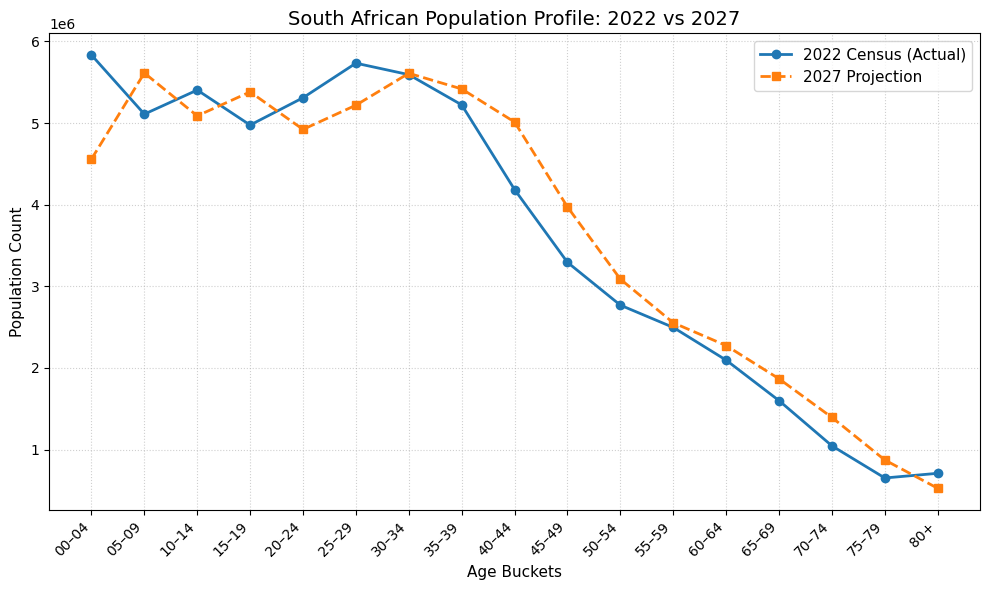

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(age_groups, n_t, marker='o', color='#1f77b4', linewidth=2, label='2022 Census (Actual)')
plt.plot(age_groups, n_2027, marker='s', color='#ff7f0e', linestyle='--', linewidth=2, label='2027 Projection')

plt.title('South African Population Profile: 2022 vs 2027', fontsize=14)
plt.xlabel('Age Buckets', fontsize=11)
plt.ylabel('Population Count', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig("Graphs/ToyModel_2022_2027_comparison.pdf", dpi=300)
plt.show()


In [12]:
# Find population growth rate (lambda) and right eigenvector/stable distribution (w)
eigenvalues, r_eigenvectors = np.linalg.eig(A)

dominant_idx = np.argmax(np.real(eigenvalues))
lam = np.real(eigenvalues[dominant_idx])

w = np.real(r_eigenvectors[:, dominant_idx])
w = w / np.sum(w) #normalise

# Find left eigenvector/reproductive value (v)
left_values, l_eigenvectors = np.linalg.eig(A.T)

left_dominant_idx = np.argmin(np.abs(left_values - lam))
v = np.real(l_eigenvectors[:, left_dominant_idx])


### Sensitivity Analysis

In [13]:
# initialise
sensitivity_F = np.zeros(17)
sensitivity_P = np.zeros(16)

v_dot_w = np.dot(v,w)

# Equation (3): Sensitivity to Fertility rates
for i in range(17):
    sensitivity_F[i] = (v[0] * w[i]) / v_dot_w

# Equation (2): Sensitivity to Survival probabilities
for i in range(16):
    sensitivity_P[i] = (v[i+1] * w[i]) / v_dot_w

In [14]:
print(f"Discrete Population Growth Rate (λ): {lam:.4f}")
print(f"Denominator (v^T * w): {v_dot_w:.4f}\n")

print("Age Group | Stable Stage (w) | Repr. Value (v) | Sens. to F_i | Sens. to P_i")
print("-" * 74)
for i in range(17):
    p_sens_str = f"{sensitivity_P[i]:.4f}" if i < 16 else "N/A"
    print(f"Group {i+1:02d}  | {w[i]:.4f}           | {v[i]:.4f}          | {sensitivity_F[i]:.4f}      | {p_sens_str}")

Discrete Population Growth Rate (λ): 0.9612
Denominator (v^T * w): -0.1620

Age Group | Stable Stage (w) | Repr. Value (v) | Sens. to F_i | Sens. to P_i
--------------------------------------------------------------------------
Group 01  | 0.0577           | -0.4501          | 0.1605      | 0.1603
Group 02  | 0.0578           | -0.4497          | 0.1606      | 0.1549
Group 03  | 0.0599           | -0.4340          | 0.1664      | 0.1543
Group 04  | 0.0621           | -0.4174          | 0.1724      | 0.1376
Group 05  | 0.0639           | -0.3591          | 0.1775      | 0.1038
Group 06  | 0.0653           | -0.2633          | 0.1815      | 0.0667
Group 07  | 0.0665           | -0.1655          | 0.1847      | 0.0327
Group 08  | 0.0670           | -0.0796          | 0.1862      | 0.0093
Group 09  | 0.0669           | -0.0225          | 0.1859      | 0.0008
Group 10  | 0.0661           | -0.0020          | 0.1835      | 0.0000
Group 11  | 0.0644           | -0.0001          | 0.1790      

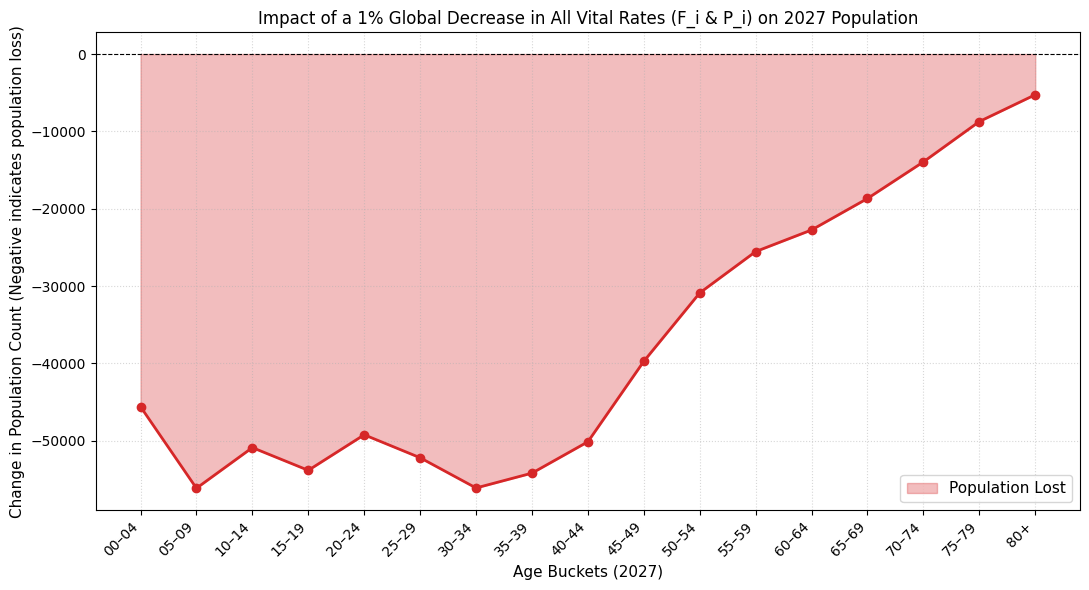

Total baseline population projected for 2027: 63,367,909
Total population with a 1% global vital rate drop: 62,734,230
Net human deficit caused by a 1% shift: -633,679


In [15]:
n_2027_baseline = A.dot(n_t)

# Perturb the ENTIRE matrix by dropping every element by 1%
A_global_perturbed = A * 0.99

n_2027_global_perturbed = A_global_perturbed.dot(n_t)

global_drop = n_2027_global_perturbed - n_2027_baseline

plt.figure(figsize=(11, 6))

# Plotting the population loss as a clear area/line chart to show the systemic shift
plt.fill_between(age_groups, global_drop, color='#d62728', alpha=0.3, label='Population Lost')
plt.plot(age_groups, global_drop, color='#d62728', marker='o', linewidth=2)

plt.title('Impact of a 1% Global Decrease in All Vital Rates (F_i & P_i) on 2027 Population', fontsize=12)
plt.xlabel('Age Buckets (2027)', fontsize=11)
plt.ylabel('Change in Population Count (Negative indicates population loss)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig("Graphs/global_sensitivity_perturbation.pdf", dpi=300)
plt.show()

# Print the overall macro impact
total_loss = np.sum(global_drop)
print(f"Total baseline population projected for 2027: {int(round(np.sum(n_2027_baseline))):,}")
print(f"Total population with a 1% global vital rate drop: {int(round(np.sum(n_2027_global_perturbed))):,}")
print(f"Net human deficit caused by a 1% shift: {int(round(total_loss)):,}")

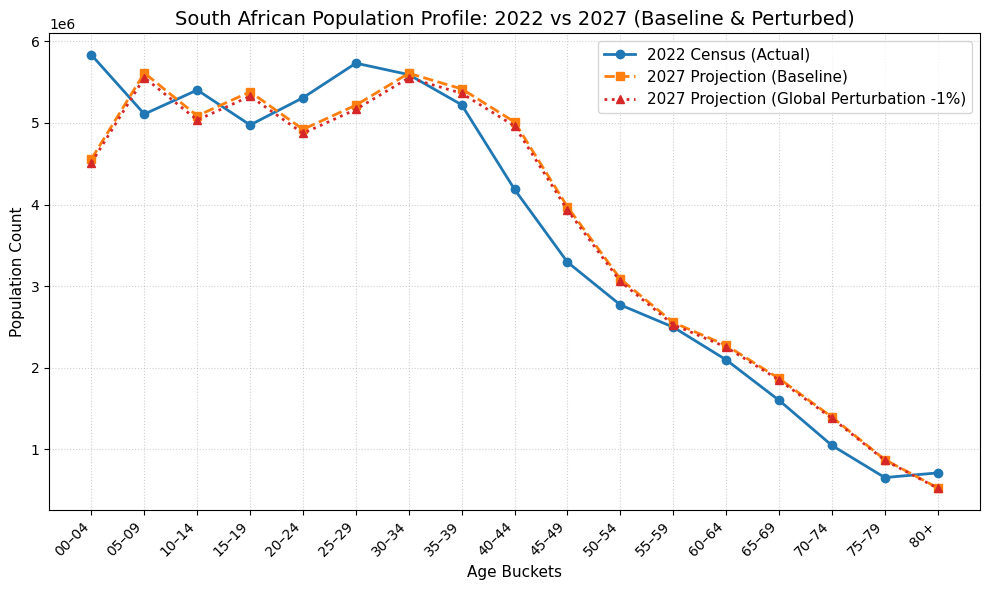

In [16]:
plt.figure(figsize=(10, 6))

# Plot 2022 Actual Data
plt.plot(age_groups, n_t, marker='o', color='#1f77b4', linewidth=2, 
         label='2022 Census (Actual)')

# Plot 2027 Baseline Projection
plt.plot(age_groups, n_2027, marker='s', color='#ff7f0e', linestyle='--', linewidth=2, 
         label='2027 Projection (Baseline)')

# Plot 2027 Globally Perturbed Projection 
plt.plot(age_groups, n_2027_global_perturbed, marker='^', color='#d62728', linestyle=':', linewidth=2, 
         label='2027 Projection (Global Perturbation -1%)')

plt.title('South African Population Profile: 2022 vs 2027 (Baseline & Perturbed)', fontsize=14)
plt.xlabel('Age Buckets', fontsize=11)
plt.ylabel('Population Count', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig("Graphs/ToyModel_peturbed_comparison.pdf", dpi=300)
plt.show()

## A Markov Chain model of the life cycle
### Individual stochasticity
A limitation of the above model is that it is deterministic and individuals have the same probability of survival given their age group. This is of course illogical as, in reality, individuals will have lives of different length due to the vagaries of mortality and survival. Demographic analysis should account for differnces among individuals and the way in which those differences affect vital rates.

Markov chain theory distinguishes between recurrent and transient states. A
recurrent state has the property that the probability of returning to that state at least once is 1. A transient state is one for which that probability is less than 1. If a Markov chain contains transient states, it will eventually leave those states and arrive in a recurrent state or class of states, where it will remain permanently. Such a chain is called absorbing. Absorbing chains are the basic model for the demography of individuals because life is inherently transient. Any individual will, with probability one, eventually leave the set of living states and be absorbed by death. In demographic models, individuals move among a set of transient (i.e., living) states, like age group, in their life cycle before they eventually reach an absorbing state (death).

We can decompose the baseline projection matrix $\mathbf{A}$ into a transient survival (or transition) matrix $\mathbf{U}$, containing the survival probabilities, and a separate fertility matrix $\mathbf{F}$ such that 
$$\mathbf{A} = \mathbf{U} + \mathbf{F}$$

For the absorbing Markov chain, we require the fundamental matrix $\mathbf{N}$ which can be found using the transition matrix $\mathbf{U}$:
$$\mathbf{N} = (\mathbf{I}-\mathbf{U})^{-1}$$

where each element $n_{ij}$ denotes the expected number of 5-year periods an individual in age bucket $j$ will spend in age bucket $i$ before they die. From the fundamental matrix $N$, we can derive the first and second moments of an individual's life expectancy $\mathbf{\eta}$:

$$ E(\mathbf{\eta})^T= \mathbf{\eta}_1^T=\mathbf{1^T N}$$
$$\mathbf{\eta}_2^T=\mathbf{\eta}_1^T(2\mathbf{N}-\mathbf{1})$$

It follows that the variance and standard deviation of life expectancy are:

$$ V(\mathbf{\eta})T = \mathbf{\eta}_2-\mathbf{\eta}_1 \circ\mathbf{\eta}_1$$
$$ SD(\mathbf{\eta})=\sqrt{V(\mathbf{\eta}})$$

where the square root is taken element wise. 

-> unsure of heterogeneity in individuals vs individual stochasticity (Chapter 5 5.1.2, Sensitivity Analysis, Caswell)





### MC model

In [57]:
s = len(age_groups)

# We constructtransient matrix U
# note we set the survival probability of 80+ as 0 (as per caswell 4.3.1)

P_annual = (n_t - deaths) / n_t
P_5year = P_annual ** 5

# Only the 5-year survivors graduate to the next bucket
U = np.zeros((s, s))
for i in range(s - 1):
    U[i + 1, i] = P_5year[i]

F_stoch = births/n_t

# then we find the fundamental matrix N
I = np.eye(s)
N = np.linalg.inv(I - U)

A_MC = U + F_stoch 

n_2027_MC = A_MC.dot(n_t)

In [58]:
step_length = 5

# mean remaining life expectancy
eta_1 = np.ones(s) @ N
# second moment of life expectancy
eta_2 = eta_1 @ (2 * N - I)

variance_steps = eta_2 - (eta_1 ** 2) # variance in each 1 year step
step_length = 5
life_expectancy_years = eta_1 * step_length

# Variance in life expectancy  
variance_years = variance_steps * (step_length ** 2) # scaled by step length^2
# SD of life expectancy
sd_years = np.sqrt(variance_years)

In [59]:
# Assuming age_groups, eta_1, life_expectancy_years, variance_steps, variance_years, and sd_years are calculated
print(f"| {'Age Group':<15} | {'Mean Steps (η1)':<16} | {'Life Exp (Years)':<17} | {'Var (Steps)':<12} | {'Var (Years)':<12} | {'SD (Years)':<10} |")
print("|" + "-"*17 + "|" + "-"*18 + "|" + "-"*19 + "|" + "-"*14 + "|" + "-"*14 + "|" + "-"*12 + "|")

for i in range(len(age_groups)):
    print(f"| {age_groups[i]:<15} | {eta_1[i]:<16.4f} | {life_expectancy_years[i]:<17.2f} | {variance_steps[i]:<12.4f} | {variance_years[i]:<12.2f} | {sd_years[i]:<10.2f} |")

| Age Group       | Mean Steps (η1)  | Life Exp (Years)  | Var (Steps)  | Var (Years)  | SD (Years) |
|-----------------|------------------|-------------------|--------------|--------------|------------|
| 00–04           | 13.0415          | 65.21             | 18.8966      | 472.42       | 21.74      |
| 05–09           | 12.5146          | 62.57             | 13.7188      | 342.97       | 18.52      |
| 10–14           | 11.5630          | 57.81             | 13.2166      | 330.42       | 18.18      |
| 15–19           | 10.6073          | 53.04             | 12.8019      | 320.05       | 17.89      |
| 20–24           | 9.7115           | 48.56             | 11.9288      | 298.22       | 17.27      |
| 25–29           | 8.8636           | 44.32             | 10.7889      | 269.72       | 16.42      |
| 30–34           | 8.0371           | 40.19             | 9.6328       | 240.82       | 15.52      |
| 35–39           | 7.2645           | 36.32             | 8.2920       | 207.30  

<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
/var/folders/f0/f0p1_xb554x3crm89t26081c0000gn/T/ipykernel_47181/3098712105.py:3: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(age_groups, life_expectancy_years, color='#1f77b4', marker='o', linewidth=2.5, label='Life Expectancy ($\eta_1$)')


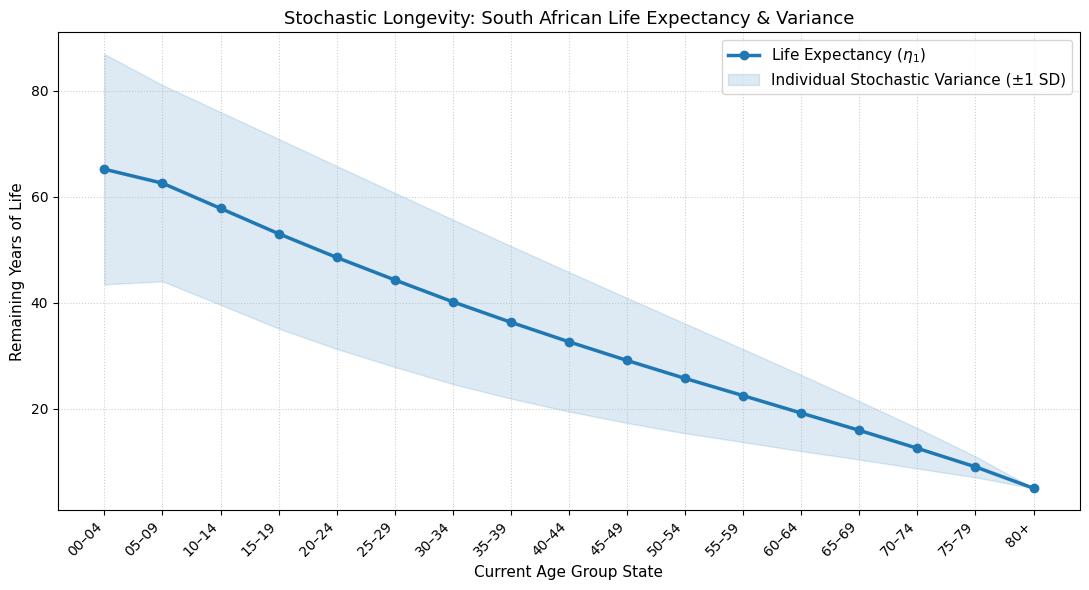

Stochastic Life Expectancy at birth: 65.21 years
Standard Deviation of Lifespan at birth: 21.74 years
Life Expectancy at 80+: 5.00 years
Standard Deviation at 80+: 0.00 years


In [60]:
plt.figure(figsize=(11, 6))

plt.plot(age_groups, life_expectancy_years, color='#1f77b4', marker='o', linewidth=2.5, label='Life Expectancy ($\eta_1$)')

lower_bound = np.maximum(0, life_expectancy_years - sd_years)
upper_bound = life_expectancy_years + sd_years

plt.fill_between(age_groups, lower_bound, upper_bound, color='#1f77b4', alpha=0.15,
                 label='Individual Stochastic Variance (±1 SD)')
plt.title('Stochastic Longevity: South African Life Expectancy & Variance', fontsize=13)
plt.xlabel('Current Age Group State', fontsize=11)
plt.ylabel('Remaining Years of Life', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig("Graphs/stochastic_longevity.pdf", dpi=300)
plt.show()

print(f"Stochastic Life Expectancy at birth: {life_expectancy_years[0]:.2f} years")
print(f"Standard Deviation of Lifespan at birth: {sd_years[0]:.2f} years")
print(f"Life Expectancy at 80+: {life_expectancy_years[-1]:.2f} years")
print(f"Standard Deviation at 80+: {sd_years[-1]:.2f} years")

In [61]:
# Print Header Formatting
print(f"{'Age Bucket':<12} | {'2022 Census':<14} | {'2027 Stoch':<14} | {'Absolute Change':<17} | {'% Change':<10}")
print("-" * 78)

for i in range(len(age_groups)):
    absolute_diff = n_2027_MC[i] - n_t[i]
    percentage_diff = (absolute_diff / n_t[i]) * 100
    
    print(f"{age_groups[i]:<12} | {n_t[i]:>14,} | {n_2027_MC[i]:>14,} | {absolute_diff:>+17,} | {percentage_diff:>+9.2f}%")

total_2022 = np.sum(n_t)
total_2027 = np.sum(n_2027_MC)
total_absolute_diff = total_2027 - total_2022
total_percentage_diff = (total_absolute_diff / total_2022) * 100

print("-" * 78)
print(f"{'TOTAL':<12} | {total_2022:>14,} | {total_2027:>14,} | {total_absolute_diff:>+17,} | {total_percentage_diff:>+9.2f}%")

Age Bucket   | 2022 Census    | 2027 Stoch     | Absolute Change   | % Change  
------------------------------------------------------------------------------
00–04        |      5,833,515 |      911,744.0 |      -4,921,771.0 |    -84.37%
05–09        |      5,109,104 | 6,524,745.934539272 | +1,415,641.9345392724 |    +27.71%
10–14        |      5,404,124 | 5,999,453.924874771 | +595,329.9248747714 |    +11.02%
15–19        |      4,975,309 | 6,293,285.8404526105 | +1,317,976.8404526105 |    +26.49%
20–24        |      5,309,738 | 5,833,668.609154551 | +523,930.6091545513 |     +9.87%
25–29        |      5,733,239 | 6,130,368.90371365 | +397,129.90371365007 |     +6.93%
30–34        |      5,592,823 | 6,521,240.360640232 | +928,417.3606402325 |    +16.60%
35–39        |      5,222,603 | 6,329,486.426635642 | +1,106,883.4266356416 |    +21.19%
40–44        |      4,185,220 | 5,924,058.129042792 | +1,738,838.1290427921 |    +41.55%
45–49        |      3,293,511 | 4,883,871.384257493 | +1

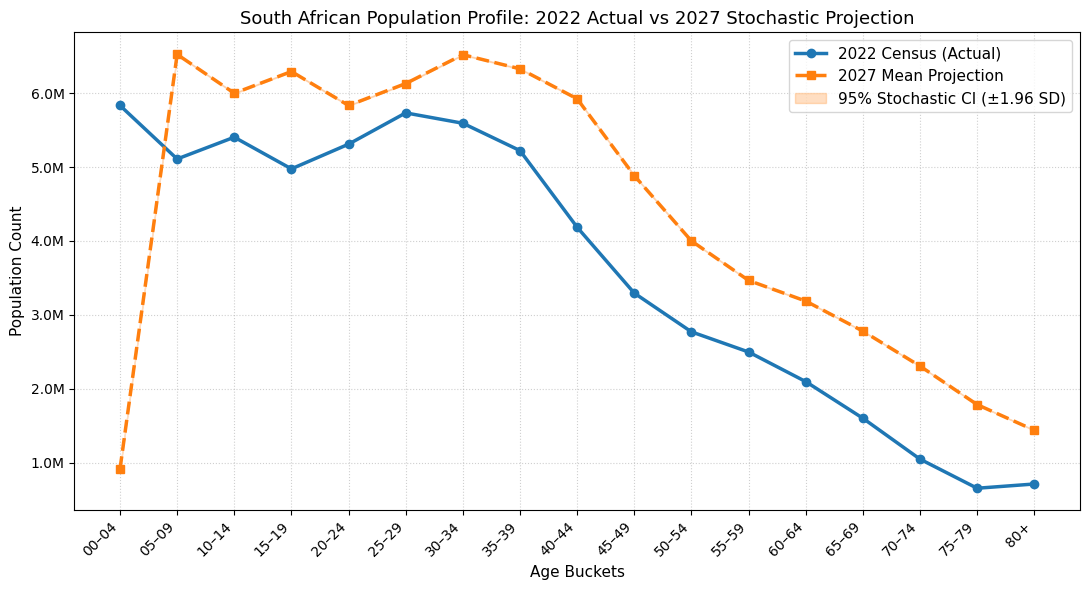

In [62]:
import matplotlib.ticker as ticker

sd_2027 = np.sqrt(n_2027_MC)
ci_lower = np.maximum(0, n_2027_MC - 1.96 * sd_2027)
ci_upper = n_2027_MC + 1.96 * sd_2027

plt.figure(figsize=(11, 6))
# Plot 2022 baseline actual profile
plt.plot(age_groups, n_t, marker='o', color='#1f77b4', linewidth=2.5, label='2022 Census (Actual)')

# Plot 2027 expected mean profile
plt.plot(age_groups, n_2027_MC, marker='s', color='#ff7f0e', linestyle='--', linewidth=2.5, label='2027 Mean Projection')

# Shade the true 95% Individual Stochastic Confidence Interval Band
plt.fill_between(age_groups, ci_lower, ci_upper, color='#ff7f0e', alpha=0.25, label='95% Stochastic CI (±1.96 SD)')

plt.title('South African Population Profile: 2022 Actual vs 2027 Stochastic Projection', fontsize=13)
plt.xlabel('Age Buckets', fontsize=11)
plt.ylabel('Population Count', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M' if x > 0 else '0'))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig("Graphs/2022_vs_2027_stochastic_confidence_intervals.pdf", dpi=300)
plt.show()

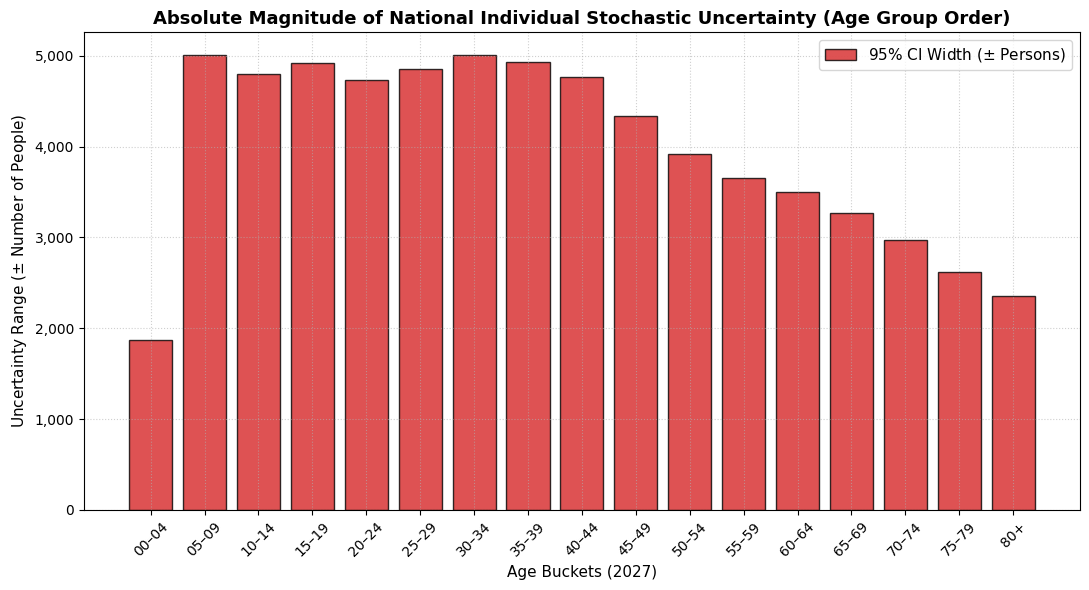

In [63]:
margin_of_error_national = 1.96 * np.sqrt(n_2027_MC)

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(age_groups, margin_of_error_national, color='#d62728', alpha=0.8, edgecolor='black', 
       label='$95\\%$ CI Width ($\\pm$ Persons)')

ax.set_title('Absolute Magnitude of National Individual Stochastic Uncertainty (Age Group Order)', fontsize=13, fontweight='bold')
ax.set_ylabel('Uncertainty Range ($\\pm$ Number of People)', fontsize=11)
ax.set_xlabel('Age Buckets (2027)', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(fontsize=11, loc='upper right')

# Format Y-axis to read cleanly with commas
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))

plt.tight_layout()
plt.savefig("Graphs/national_stochastic_magnitude_chronological.png", dpi=300)
plt.show()

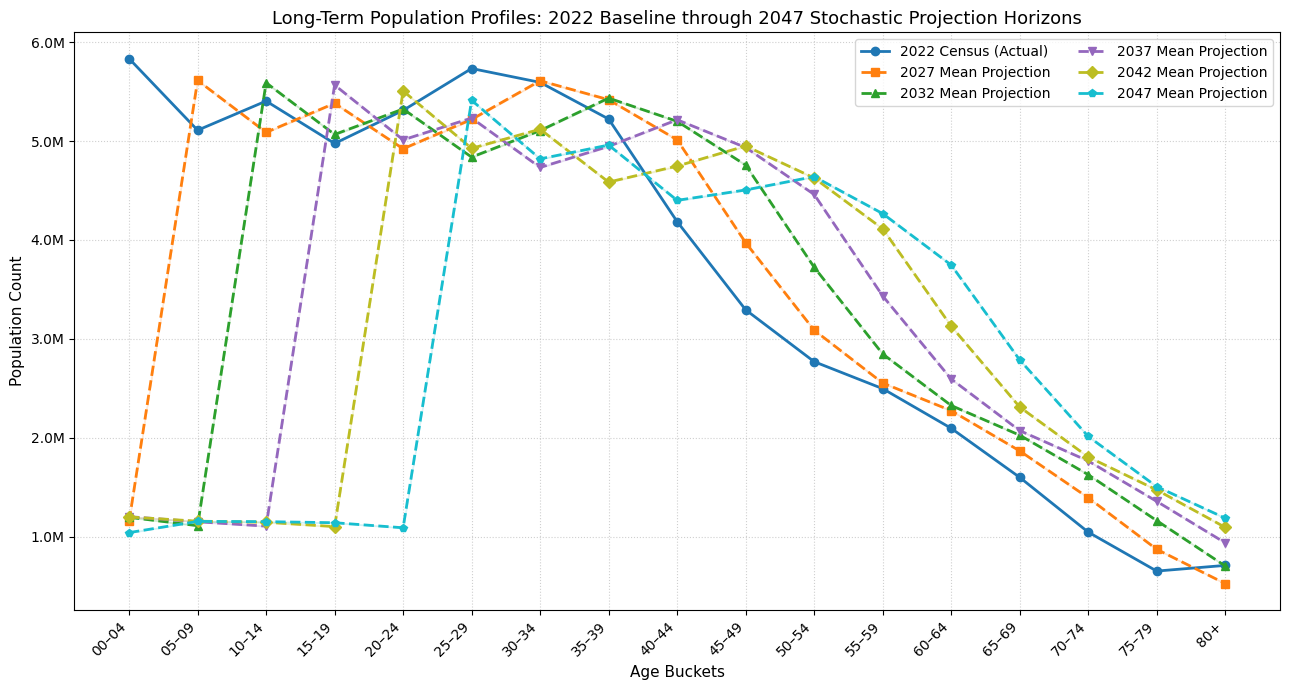

In [64]:
f = np.zeros(s)
reproductive_indices = [3, 4, 5, 6, 7, 8, 9]  
total_reproductive_pop = np.sum(n_t[reproductive_indices])
target_births = 1154567  
flat_fertility_rate = target_births / total_reproductive_pop
for idx in reproductive_indices:
    f[idx] = flat_fertility_rate

A = np.copy(U)
A[0, :] = f

projections = {2022: n_t}
current_vector = np.copy(n_t)

years = [2027, 2032, 2037, 2042, 2047]
for year in years:
    current_vector = A @ current_vector
    projections[year] = current_vector

plt.figure(figsize=(13, 7))

plot_years = [2022, 2027, 2032, 2037, 2042, 2047]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#bcbd22', '#17becf']
markers = ['o', 's', '^', 'v', 'D', 'p']

for i, yr in enumerate(plot_years):
    n_yr = projections[yr]
    
    # Calculate unique individual demographic variance per year
    sd_yr = np.sqrt(n_yr)
    ci_low = np.maximum(0, n_yr - 1.96 * sd_yr)
    ci_up = n_yr + 1.96 * sd_yr
    
    linestyle = '-' if yr == 2022 else '--'
    label_main = '2022 Census (Actual)' if yr == 2022 else f'{yr} Mean Projection'
    
    # Plot expected value profiles
    plt.plot(age_groups, n_yr, marker=markers[i], color=colors[i], 
             linestyle=linestyle, linewidth=2, label=label_main)
    
    # Shade matching 95% Confidence Interval bands for projection layers
    if yr != 2022:
        plt.fill_between(age_groups, ci_low, ci_up, color=colors[i], alpha=0.15)

plt.title('Long-Term Population Profiles: 2022 Baseline through 2047 Stochastic Projection Horizons', fontsize=13)
plt.xlabel('Age Buckets', fontsize=11)
plt.ylabel('Population Count', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M' if x > 0 else '0'))
plt.grid(True, linestyle=':', alpha=0.6)

plt.legend(fontsize=10, loc='upper right', ncol=2)
plt.tight_layout()

plt.savefig("Graphs/multi_year_stochastic_projections.pdf", dpi=300)
plt.show()

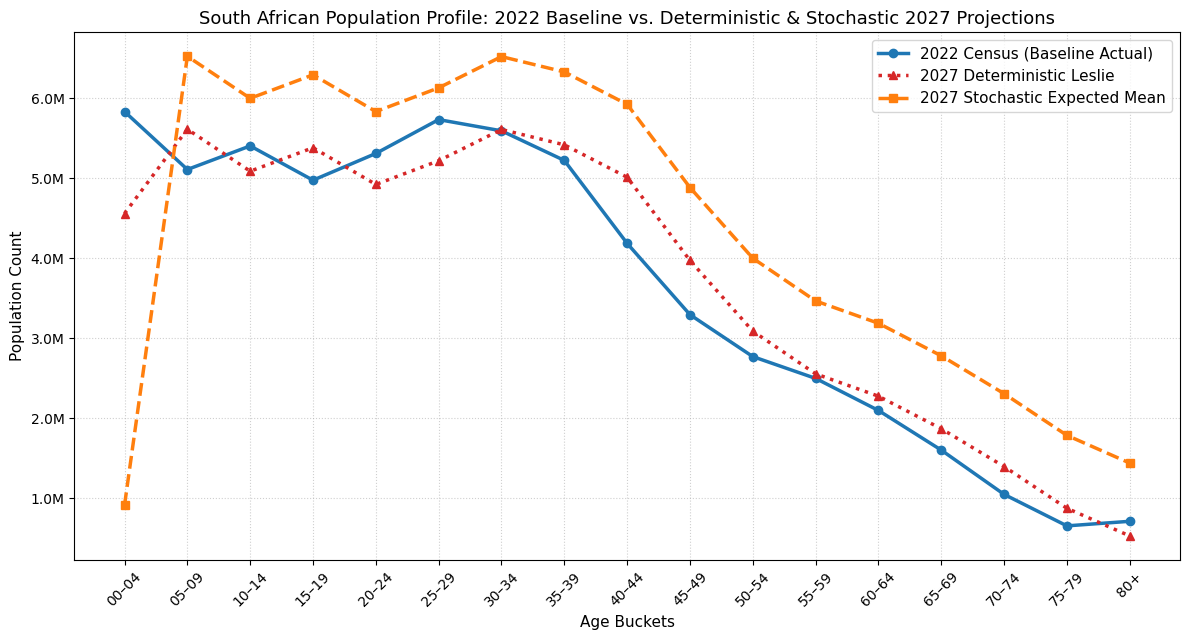

In [65]:
fig, ax = plt.subplots(figsize=(12, 6.5))

ax.plot(age_groups, n_t, marker='o', color='#1f77b4', linewidth=2.5, 
        label='2022 Census (Baseline Actual)')

# Plot 2027 Deterministic Leslie Model 
ax.plot(age_groups, n_2027, marker='^', color='#d62728', linestyle=':', linewidth=2.5, 
        label='2027 Deterministic Leslie')

# Plot 2027 MC model
ax.plot(age_groups, n_2027_MC, marker='s', color='#ff7f0e', linestyle='--', linewidth=2.5, 
        label='2027 Stochastic Expected Mean')

ax.set_title('South African Population Profile: 2022 Baseline vs. Deterministic & Stochastic 2027 Projections', fontsize=13)
ax.set_xlabel('Age Buckets', fontsize=11)
ax.set_ylabel('Population Count', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, linestyle=':', alpha=0.6)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M' if x > 0 else '0'))
ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig("Graphs/model_comparison_2022_2027.pdf", dpi=300)
plt.show()